# Test code for propagation/contribution/etc

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
"""
This cell does the initial project setup.
If you start a new script or notebook, make sure to copy & paste this part.

A script with this code uses the location of the `.env` file as the anchor for
the whole project (= PROJECT_ROOT). Afterwards, code inside the `src` directory
are available for import.
"""
from pathlib import Path
import sys
from dotenv import load_dotenv, find_dotenv
load_dotenv()
PROJECT_ROOT = Path(find_dotenv()).parent
sys.path.append(str(PROJECT_ROOT.joinpath('src')))
print(f"Project root directory: {PROJECT_ROOT}")

Project root directory: c:\Users\artxz\Dropbox (HHMI)\sync_userA\Documents\ReiserGroup\p_ol_connectome\github_ol_analysis


In [4]:
from utils import olc_client
c = olc_client.connect(verbose=True)

Connected to https://neuprint-cns.janelia.org[cns].
Client: neuprint-python v1.7.4
User: artxzhao@gmail.com [readwrite]



In [5]:
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt

import cmap

import pandas as pd
import numpy as np
import pickle as pkl
import re
import os, datetime
import networkx as nx
# from openpyxl.styles import Font

In [6]:
import neuprint
# print(neuprint.__version__)
from neuprint import fetch_neurons, fetch_synapses, fetch_adjacencies
from neuprint import NeuronCriteria as NC, SynapseCriteria as SC
# from neuprint.queries import fetch_all_rois, fetch_roi_hierarchy

import navis
import navis.interfaces.neuprint as neu

# test path finding

In [7]:
# 79849 -> 100018 and 79849 -> 96081 -> 100018 

paths = neuprint.fetch_paths(upstream_bodyId=79849, downstream_bodyId=100018, max_path_length=2)

In [11]:
paths.iloc[48:51]

,path,bodyId,type,weight,path_length
48,16,79849,Tm3,0,2
49,16,96081,T4a,8,2
50,16,100018,T4a,2,2


In [12]:
paths[paths.path_length == 1]

,path,bodyId,type,weight,path_length
51,17,79849,Tm3,0,1
52,17,100018,T4a,3,1


# test adj_trans_matrix

In [16]:
from utils.graph_utils import adj_trans_matrix
m_adj, m_trans, neuron_df = adj_trans_matrix([79849, 96081, 100018 ], min_total_weight=1)

In [17]:
m_adj

bodyId_post,79849,96081,100018
bodyId_pre,,,
79849,0.0,0.024242,0.011494
96081,0.0,0.000000,0.007663
100018,0.0,0.000000,0.000000


In [19]:
m_trans

bodyId_pre,79849,96081,100018
bodyId_post,,,
79849,0.000000,0.000000,0.0
96081,0.024242,0.000000,0.0
100018,0.011494,0.007663,0.0


# test c-score 

In [ ]:
A = np.array([[0,1],[1,0]])
0.3 ** A

In [13]:
# el = np.array([[0,1,0],
#                [0,2,0.5],
#                [1,2, 0.5],
#                [1,3,0.5]])
# seeds = [0]

el = np.array([
   [1,0,50],
   [2,0,50],
   [1,2,10],
   [3,2,20],
   [4,2,20],
   ])
# seeds = [0, 1]

edges = pd.DataFrame(el, columns=['source', 'target', 'weight'])
# specify data types
edges = edges.astype({'source': 'int64', 'target': 'int64', 'weight': 'float64'})
edges

,source,target,weight
0,1,0,50.0
1,2,0,50.0
2,1,2,10.0
3,3,2,20.0
4,4,2,20.0


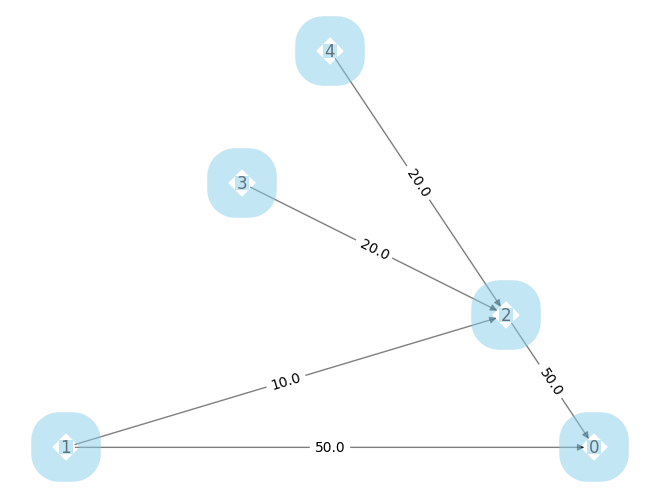

In [14]:
# make graph
G = nx.from_pandas_edgelist(edges, source='source', target='target', edge_attr='weight', create_using=nx.DiGraph)
# draw graph
# pos = nx.spring_layout(G)
# pos = nx.circular_layout(G)
pos = nx.planar_layout(G)
nx.draw(G, pos, with_labels=True, node_size=100, node_color="skyblue", node_shape="s", alpha=0.5, linewidths=40)
# draw edge labels
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.show()

In [29]:
# convert edges to adjacency matrix, with node indices
adj_matrix = nx.to_pandas_adjacency(G, dtype='float64')
# order by node index
adj_matrix = adj_matrix.sort_index(axis=0).sort_index(axis=1)
adj_matrix

,0,1,2,3,4
0,0.0,0.0,0.0,0.0,0.0
1,50.0,0.0,10.0,0.0,0.0
2,50.0,0.0,0.0,0.0,0.0
3,0.0,0.0,20.0,0.0,0.0
4,0.0,0.0,20.0,0.0,0.0


In [32]:
# normalize adj_matrix by column sums, fillna with 0
adj_matrix = adj_matrix.div(adj_matrix.sum(axis=0), axis=1).fillna(0)
adj_matrix

,0,1,2,3,4
0,0.0,0.0,0.0,0.0,0.0
1,0.5,0.0,0.2,0.0,0.0
2,0.5,0.0,0.0,0.0,0.0
3,0.0,0.0,0.4,0.0,0.0
4,0.0,0.0,0.4,0.0,0.0


In [33]:
m_trans = adj_matrix.T
m_trans

,0,1,2,3,4
0,0.0,0.5,0.5,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0
2,0.0,0.2,0.0,0.4,0.4
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0


In [35]:
v0 = [1, 0, 0, 0, 0] 

# calculate c-scores for each hop, up to 3 hops here
cscore_ls = [] # init a list
arr = m_trans.values # convert to numpy array
for i in range(1, 4):
    # print(i)
    mm = np.linalg.matrix_power(arr, i)
    contrib = v0 @ mm
    # convert to DataFrame
    contrib = pd.DataFrame(contrib,index=m_trans.index, columns=[f'{i}'])
    # contrib = pd.merge(contrib, neuron_df, left_index=True, right_on='bodyId', how='left')
    cscore_ls.append(contrib)

In [36]:
cscore_ls

[     1
 0  0.0
 1  0.5
 2  0.5
 3  0.0
 4  0.0,
      2
 0  0.0
 1  0.1
 2  0.0
 3  0.2
 4  0.2,
      3
 0  0.0
 1  0.0
 2  0.0
 3  0.0
 4  0.0]

In [ ]:
pd.concat(cscore_ls, axis=1).sum(axis=1)

0    0.0
1    0.6
2    0.5
3    0.2
4    0.2
dtype: float64